Keshia-Lee Martin<br>
DX602 - Programming Toolkit for Data Science<br>
Final Project<br>
4/26/2026

<h2>Bike Rental Demand Analysis</h2>

**Introduction**

The purpose of this project is to complete an exploratory data analytics on a data set, answering questions I'd like to investigate. The dataset I've selected is Outdoor Recreation. This dataset analyzes bike rental patterns due to the season, month, and weekday. 

From this dataset, Here are some possible questions that could be answered:

1. Which season has the highest number of bike rentals?
2. How do casual renters and registered renters differ?
3. How do the bike rentals change based on rush hour and not rush hour?
4. What hour of the day has the most riders? 
5. What month has the most riders?
6. Are the bikes ridden more by the casual riders or the registered riders?

**Load and Inspecting the Data**



This section gives a general view of the bike rental dataset, looking into the main columns, the data types, and formatting. Pandas, numpy, matplotlib, and sklearn libraries will be used for the analysis.

In [571]:
# shared imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.linear_model
plt.close("all")

The data set is loaded in and reviewed by displaying 10 random samples. This helps to see how the data is organized, how it's formatted, and what columns and categories can be cleaned up or name changed.

In [572]:
# loading the dataset
bikes = pd.read_csv("bikes_final.csv")

# displaying 10 sample rows
bikes.sample(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week
10651,2012-12-10 05:00:00,4,0,1,2,15.58,19.695,94,7.0015,0,27,27,Monday
54,2011-01-03 09:00:00,1,0,1,1,6.56,6.820,43,26.0027,7,81,88,Monday
2431,2011-06-09 05:00:00,2,0,1,2,28.70,33.335,84,0.0000,1,19,20,Thursday
5095,2011-12-06 09:00:00,4,0,1,2,18.86,22.725,94,15.0013,4,200,204,Tuesday
3702,2011-09-05 04:00:00,3,1,0,2,27.88,31.820,69,19.0012,3,5,8,Monday
1739,2011-04-18 09:00:00,2,0,1,2,20.50,24.240,55,7.0015,37,132,169,Monday
9395,2012-09-14 20:00:00,3,0,1,1,27.06,31.060,61,7.0015,67,337,404,Friday
8377,2012-07-10 10:00:00,3,0,1,1,31.16,35.605,62,12.9980,56,134,190,Tuesday
8802,2012-08-09 03:00:00,3,0,1,1,27.88,31.820,83,6.0032,1,5,6,Thursday
10664,2012-12-10 18:00:00,4,0,1,2,18.86,22.725,88,19.0012,20,544,564,Monday


Our column names are:
1. datetime - hourly date and the timestamp
2. season - seasons of the year, 1 = spring, 2 = summer, 3 = fall, 4 = winter 
3. holiday - whether the day is considered a holiday
4. workingday - whether the day is neither a weekend nor holiday
5. weather  - 
    1: Clear, Few clouds, Partly cloudy, Partly cloudy, 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist, 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds, 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
6. temp - temperature in Celsius
7. atemp - "feels like" temperature in Celsius
8. humidity - relative humidity
9. windspeed - wind speed
10. casual - number of non-registered user rentals
11. registered - number of registered user rentals
12. count - number of total rentals
13. day_of_week - days of the week

In [573]:
# checking columns
bikes.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count',
       'day_of_week'],
      dtype='object')

The datatypes in our dataset are objects, integers, and floats.

In [574]:
# checking data types
bikes.dtypes

datetime        object
season           int64
holiday          int64
workingday       int64
weather          int64
temp           float64
atemp          float64
humidity         int64
windspeed      float64
casual           int64
registered       int64
count            int64
day_of_week     object
dtype: object

This dataset does not have any missing values.

In [575]:
# checking missing values
bikes.isna().any().any()


np.False_

In [576]:
bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     10886 non-null  object 
 1   season       10886 non-null  int64  
 2   holiday      10886 non-null  int64  
 3   workingday   10886 non-null  int64  
 4   weather      10886 non-null  int64  
 5   temp         10886 non-null  float64
 6   atemp        10886 non-null  float64
 7   humidity     10886 non-null  int64  
 8   windspeed    10886 non-null  float64
 9   casual       10886 non-null  int64  
 10  registered   10886 non-null  int64  
 11  count        10886 non-null  int64  
 12  day_of_week  10886 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.1+ MB


**Data Cleaning and Preparation**



This section is preparing a cleaned up version of the data by renaming columns and changing datatypes. This will improve the data analysis, making it easier to understand and read. 

The datetime column is converted and separated into new columns by the hour, month, and year to do time analysis. The remapping will only be done for the month and year.


In [577]:
# converting the date column to pandas datetime
bikes["datetime"] = pd.to_datetime(bikes["datetime"])

# creating new columns that will be month, year, and hour
bikes["year"] = bikes["datetime"].dt.year.astype("category")
bikes["month"] = bikes["datetime"].dt.month.astype("category")
bikes["hour"] = bikes["datetime"].dt.hour.astype("category")

# remapping 'month' column to categorical
month_name = {
  1: "January",
  2: "February",
  3: "March",
  4: "April",
  5: "May",
  6: "June",
  7: "July",
  8: "August",
  9: "September",
  10: "October",
  11: "November",
  12: 'December'
}

bikes["month"] = bikes["month"].map(month_name)

#  remapping 'hour' column to categorical
hour_name = {
  0: "12am",
  1: "1am",
  2: "2am",
  3: "3am",
  4: "4am",
  5: "5am",
  6: "6am",
  7: "7am",
  8: "8am",
  9: "9am",
  10: "10am",
  11: "11am",
  12: "12pm",
  13:"1pm",
  14:"2pm",
  15:"3pm",
  16:"4pm",
  17:"5pm",
  18:"6pm",
  19:"7pm",
  20:"8pm",
  21:"9pm",
  22:"10pm",
  23:"11pm"
}

bikes["hour"] = bikes["hour"].map(hour_name)

# loading and view the table to make sure the columns are appearing as intended.
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


The seasons are remapped from the numbers to their categorical names, with the type being changed to categorical.


In [578]:
# remapping of season 1, 2, 3, 4 to spring, summer, fall, and winter
season_name = {
  1: "Spring",
  2: "Summer",
  3: "Fall",
  4: "Winter"
}

# needs to be changed from an integer to a category
bikes["season"] = bikes["season"].map(season_name).astype("category")

# to check mapping change
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,0,0,1,9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,0,0,1,9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,0,0,1,9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,0,0,1,9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,0,0,1,9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0,1,1,15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,0,1,1,14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,0,1,1,13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,0,1,1,13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


The weather conditions are remapped from the numbers to their categorical names, with the type being changed to categorical.

In [579]:
# remapping of weather 1, 2, 3, 4 to weather condition categories
weather_name = {
  1: "Clear, Few clouds, Partly cloudy",
  2: "Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist",
  3: "Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds",
  4: "Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog"
}

# needs to be changed from an integer to a category
bikes["weather"] = bikes["weather"].map(weather_name).astype("category")

# to check mapping change
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,0,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,0,1,"Clear, Few clouds, Partly cloudy",13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


Changing the day_of_week column to categorical, but also changing the order to be Monday-Sunday, not Saturday-Friday.

In [580]:
# changing day of week type to category and reordering them from S-F to M-S
week_order = ["Monday",
  "Tuesday",
  "Wednesday",
  "Thursday",
  "Friday",
  "Saturday",
  "Sunday"]
  
bikes["day_of_week"] = pd.Categorical(bikes["day_of_week"], categories=week_order, ordered=True)

# verification that the new order and categories are correct
bikes["day_of_week"].unique()


['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']

The holiday and workingday is changed from numerical to categorical strings and types.

In [581]:
#changing numerical to categorical for the holiday column
holiday_name = {
  0: "Not a Holiday",
  1: "Holiday"
}

bikes["holiday"] = bikes["holiday"].map(holiday_name).astype("category")

bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,Not a Holiday,0,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,Not a Holiday,1,"Clear, Few clouds, Partly cloudy",13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


In [582]:
# changing numerical to categorical for the working day column
workingday_name = {
  0: "Not a Workday",
  1: "Workday"
}

bikes["workingday"] = bikes["workingday"].map(workingday_name).astype("category")

# verification that all columns have been updated as intended
bikes

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,day_of_week,year,month,hour
0,2011-01-01 00:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.84,14.395,81,0.0000,3,13,16,Saturday,2011,January,12am
1,2011-01-01 01:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,8,32,40,Saturday,2011,January,1am
2,2011-01-01 02:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.02,13.635,80,0.0000,5,27,32,Saturday,2011,January,2am
3,2011-01-01 03:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,3,10,13,Saturday,2011,January,3am
4,2011-01-01 04:00:00,Spring,Not a Holiday,Not a Workday,"Clear, Few clouds, Partly cloudy",9.84,14.395,75,0.0000,0,1,1,Saturday,2011,January,4am
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",15.58,19.695,50,26.0027,7,329,336,Wednesday,2012,December,7pm
10882,2012-12-19 20:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",14.76,17.425,57,15.0013,10,231,241,Wednesday,2012,December,8pm
10883,2012-12-19 21:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",13.94,15.910,61,15.0013,4,164,168,Wednesday,2012,December,9pm
10884,2012-12-19 22:00:00,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",13.94,17.425,61,6.0032,12,117,129,Wednesday,2012,December,10pm


**Descriptive Statistics**

Summarizing the statistics for numerical columns and the categorical columns.

There are 7 numerical columns. They are temp, atemp, humidity, windspeed, casual, registered, and count. There are 10,886 lines of data and as noted before, no data values are missing.

In [583]:
# descriptive statistics for numerical columns
summary_numerical = bikes.describe(include="number")
summary_numerical

,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


There are 9 categorical columns. They are season, holiday, workingday, weather, day_of_week, year, month, hour, and weekend_weekday. There are 10,886 lines of data and as noted before, no data values are missing.

Using this table, it's confirmed that the correct number of seasons, days of the week, months, and hours are in the data. It's also verifies that the data is appearing and has been cleaned up as intended by looking at holiday and weekend_weekday. For weekend_weekday, there are more weekdays than weekends. For holiday, there are more days without holidays than there are with.

In [584]:
# summary for categorical columns - excluding month, day, hour, from separately printed 
print(bikes["season"].value_counts())
print()
print(bikes["holiday"].value_counts())
print()
print(bikes["workingday"].value_counts())
print()
print(bikes["weather"].value_counts())
print()
print(bikes["day_of_week"].value_counts())
print()
print(bikes["year"].value_counts())


summary_categorical = bikes.describe(include="category")
summary_categorical

season
Winter    2734
Fall      2733
Summer    2733
Spring    2686
Name: count, dtype: int64

holiday
Not a Holiday    10575
Holiday            311
Name: count, dtype: int64

workingday
Workday          7412
Not a Workday    3474
Name: count, dtype: int64

weather
Clear, Few clouds, Partly cloudy                                                           7192
Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist                               2834
Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds     859
Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog                                    1
Name: count, dtype: int64

day_of_week
Saturday     1584
Sunday       1579
Thursday     1553
Monday       1551
Wednesday    1551
Tuesday      1539
Friday       1529
Name: count, dtype: int64

year
2012    5464
2011    5422
Name: count, dtype: int64


,season,holiday,workingday,weather,day_of_week,year,month,hour
count,10886,10886,10886,10886,10886,10886,10886,10886
unique,4,2,2,4,7,2,12,24
top,Winter,Not a Holiday,Workday,"Clear, Few clouds, Partly cloudy",Saturday,2012,May,12pm
freq,2734,10575,7412,7192,1584,5464,912,456


**Numeric Data Visualizations**

Creating histograms that show the distribution of numerical data for temp, atemp, humidity, windspeed, casual, registered, and count.

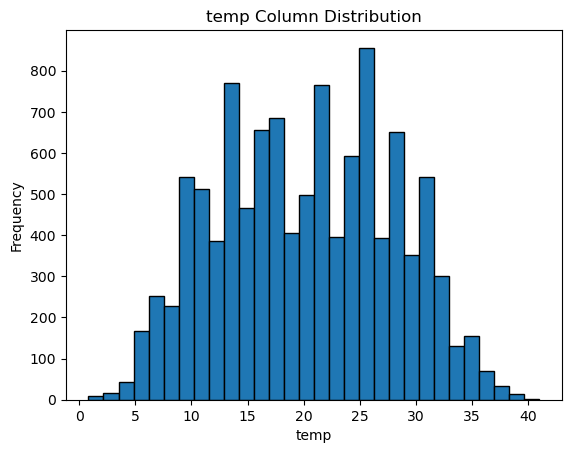

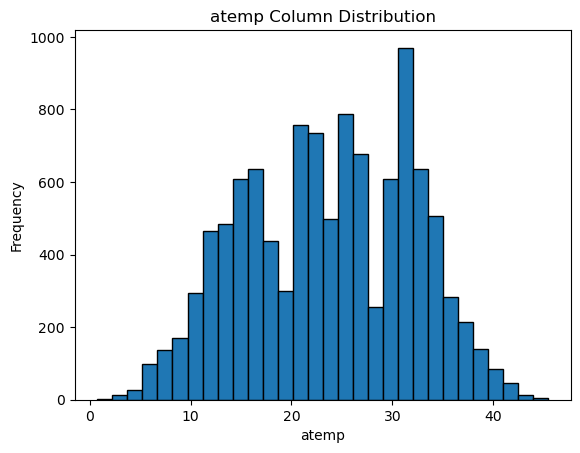

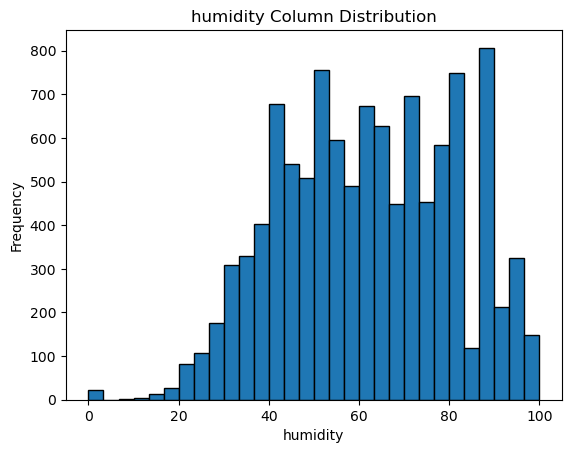

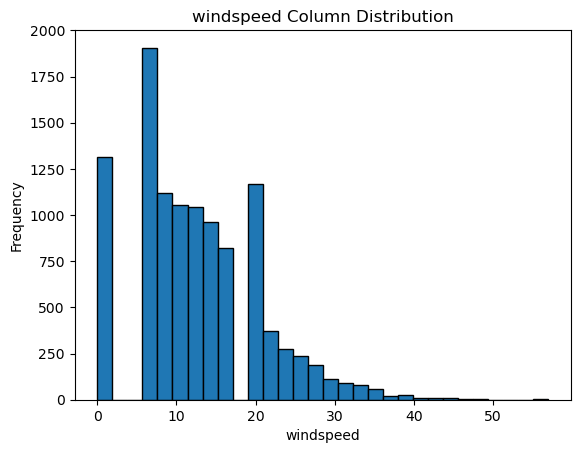

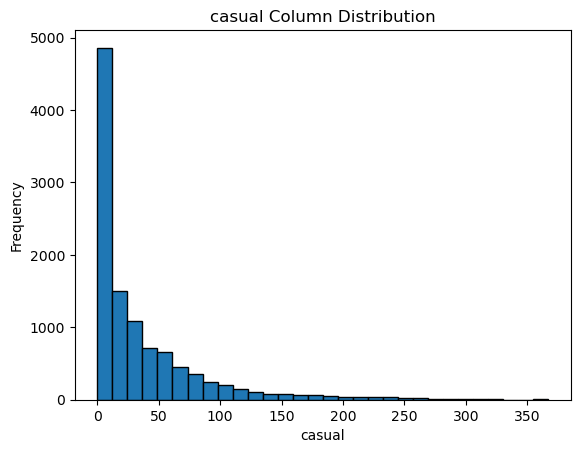

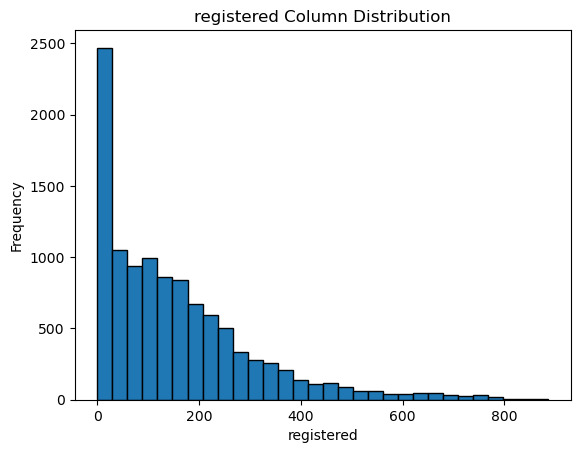

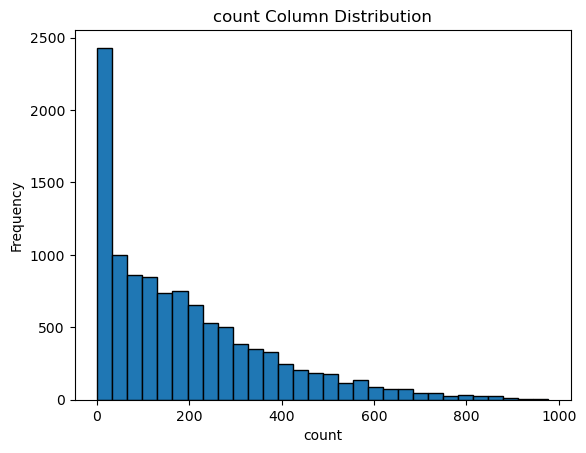

In [585]:
# created a list for all of the numerical columns
columns_numerical = [
  "temp", 
  "atemp", 
  "humidity", 
  "windspeed",
  "casual",
  "registered",
  "count"
]

# for loop to plot each of the column histograms to analyze its distribution
for column in columns_numerical:
  plt.hist(bikes[column], edgecolor="black", bins=30)
  plt.title(f"{column} Column Distribution")
  plt.xlabel(f"{column}")
  plt.ylabel("Frequency")
  plt.show()




1. The temperature (temp) histogram shows a fairly normal distribution with most of the recorded days being between roughly 8 and 32 dregrees.
2. The "feels like" temperature (atemp) histogram looks simiar to the tempurature histogram, but is shifted higher.
3. The humidity distribution is left-skewed, most of the records being between roughly 30 and 90 humidity levels.
4. The windspeed distribution is right-skewed, with most of the records falling below 20. Looking at the histogram, there are some visible outliers.
5. The non-registered (casual) users distribution is right-skewed, with most records having a number below 50 of non-registered riders. Looking at the histogram, there are some visible outliers.
6. The registered users distribution is also right-skewed, with most records having below 200 of reigistered riders. Looking at the histogram, there are some visible outliers.
7. The total bike rental count (count) distribution is right-skewed, showing that high rental days aren't as common. Looking at the histogram, there are some visible outliers.


**Categorical Data Analysis**

For the categorical analysis, pie charts were created for season, holiday, workingday, weather, day_of_week, year, month, hour, and weekend_weekday, displaying the information as percentages.

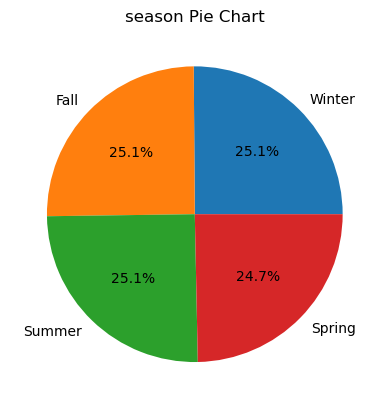

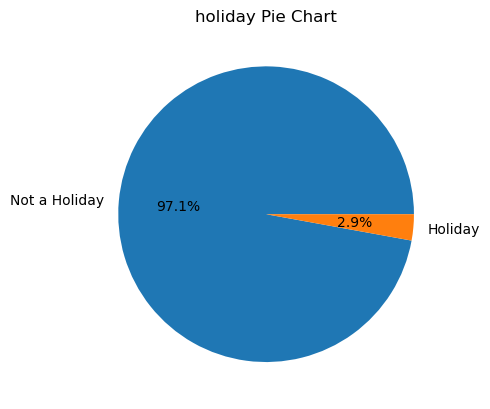

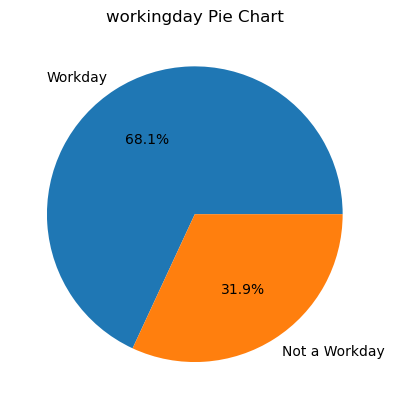

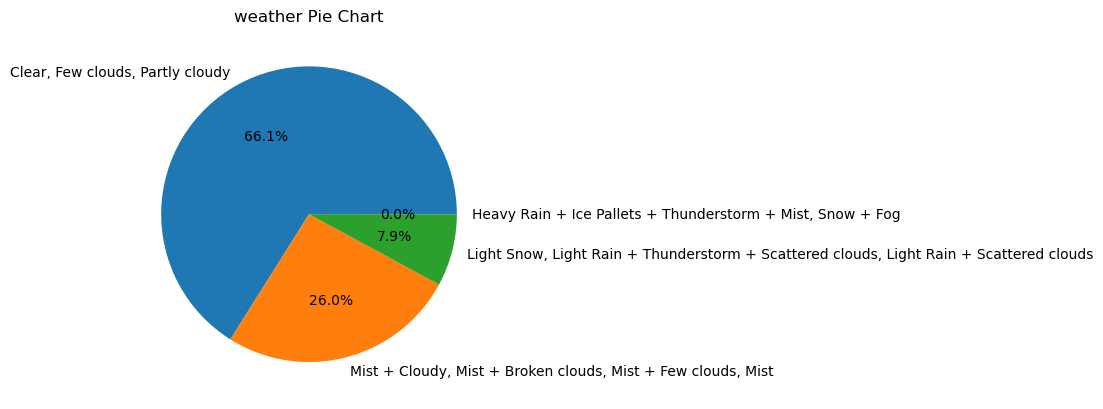

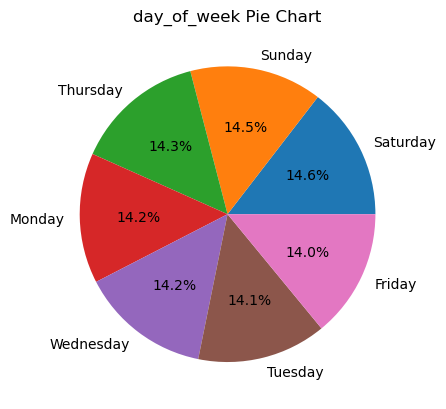

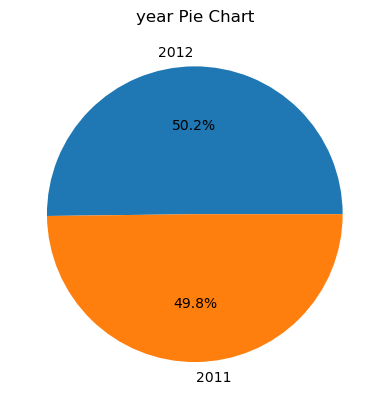

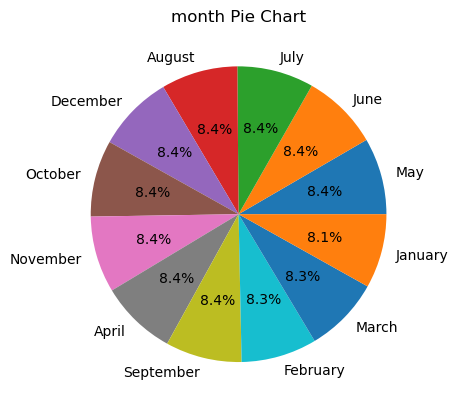

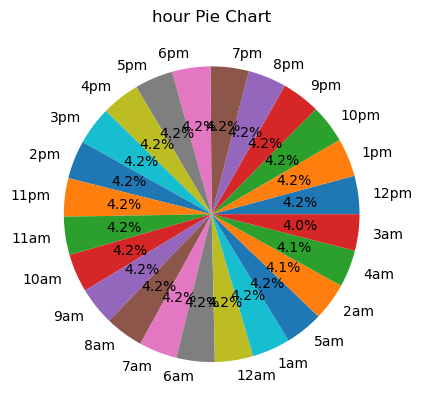

In [586]:
# list for season, holiday, workingday, weather, day_of_week, year, month, hour, and weekend_weekday
columns_categorical = [
  "season",
  "holiday",
  "workingday",
  "weather",
  "day_of_week",
  "year",
  "month",
  "hour"
]

# for loop to display all pie charts for all of the categorical columns
for column in columns_categorical:
  bikes[column].value_counts().plot(kind="pie", autopct="%1.1f%%")
  plt.title(f"{column} Pie Chart")
  plt.ylabel("")
  plt.show()

**Grouped Analysis**

For the grouped analysis, the data will be season and looking at the casual renters, the registered renters, and the total amount of renters for that specific season.

In [587]:
# creating a variable to group by the season category
rentals_season = bikes.groupby("season")[["casual", "registered", "count"]].sum()
rentals_season

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\4145237380.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rentals_season = bikes.groupby("season")[["casual", "registered", "count"]].sum()


,casual,registered,count
season,,,
Fall,142718,497944,640662
Spring,41605,270893,312498
Summer,129672,458610,588282
Winter,78140,465894,544034


In [588]:
season_stats = bikes.groupby("season")[["casual", "registered", "count"]].describe()
season_stats

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\1778592143.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_stats = bikes.groupby("season")[["casual", "registered", "count"]].describe()


casual                                                     registered  \
         count       mean        std  min   25%   50%   75%    max      count   
season                                                                          
Fall    2733.0  52.220271  54.638059  0.0  10.0  36.0  74.0  350.0     2733.0   
Spring  2686.0  15.489576  31.222498  0.0   1.0   5.0  15.0  367.0     2686.0   
Summer  2733.0  47.446762  57.649556  0.0   8.0  29.0  63.0  361.0     2733.0   
Winter  2734.0  28.580834  42.596214  0.0   4.0  14.0  33.0  362.0     2734.0   

                    ...                  count                               \
              mean  ...     75%    max   count        mean         std  min   
season              ...                                                       
Fall    182.196853  ...  252.00  886.0  2733.0  234.417124  197.151001  1.0   
Spring  100.853686  ...  141.00  681.0  2686.0  116.343261  125.273974  1.0   
Summer  167.804610  ...  243.00  782.0  2733.0  215.251372  192.007843  1.0   
Winter  170.407462  ...  238.75  857.0  2734.0  198.988296  177.622409  1.0   

                                   
         25%    50%    75%    max  
season                             
Fall    68.0  195.0  347.0  977.0  
Spring  24.0   78.0  164.0  801.0  
Summer  49.0  172.0  321.0  873.0  
Winter  51.0  161.0  294.0  948.0  

[4 rows x 24 columns]

Based on the information about and the bar graph below, we now know the following:

1. Fall has the most total bike rentals, for both casual and registered bike renters.
2. Spring has the least amount of total bike rentals, for both casual and registered bike renters. 

For Spring to have the lowest amount of bike rentals is interesting, as it tends to be warmer than the winter. But, weather can come into play with more rain and storms in the transition into Summer.


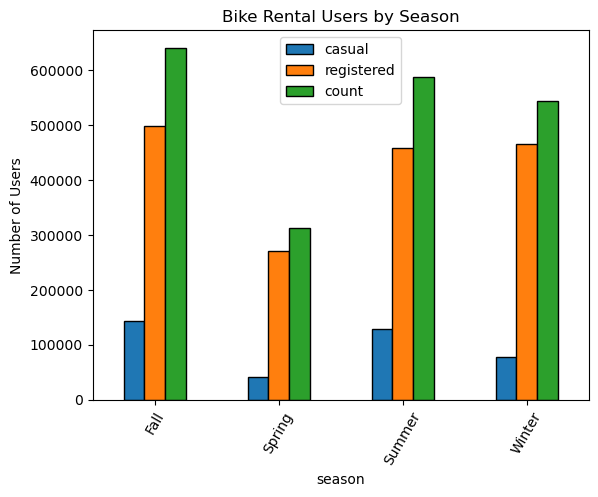

In [589]:
# bar graph
rentals_season.plot(kind="bar", edgecolor="black")
plt.title("Bike Rental Users by Season")
plt.ylabel("Number of Users")
plt.xticks(rotation=60)
plt.show()

**New Feature Engineering**

I created a new column for rush hour for the hours 7am-9am and 4pm-6pm. This can be used to determine the number of bike rentals by casual and registered renters, as well as the total. It's convienent to see the differences if there are in fact more rentals during those hours.

In [590]:
# creating a column for rush hour for am 7am-9am, evening 4pm-6pm
bikes["rush_hour"] = np.where(bikes["hour"].isin(["7am", "8am", "9am", "4pm", "5pm", "6pm"]), "Rush Hour", "Not Rush Hour")

# changed from object to category
bikes["rush_hour"] = bikes["rush_hour"].astype("category")

# verifying that the column is appearing as intended
# bikes.sample(10)
# bikes.dtypes

# grouping for users
rentals_rush_hour = bikes.groupby("rush_hour")[["casual", "registered", "count"]].sum()
print(rentals_rush_hour)
print()
print('Descriptive Statistics - Rush Hour (sum of users)')
print(rentals_rush_hour.describe())

print()
print('Descriptive Statistics - Rush Hour')
print()
stats_rush_hour = bikes.groupby("rush_hour")[["casual", "registered", "count"]].describe()
print(stats_rush_hour)

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\543735271.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rentals_rush_hour = bikes.groupby("rush_hour")[["casual", "registered", "count"]].sum()
C:\Users\19143\AppData\Local\Temp\ipykernel_24320\543735271.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_rush_hour = bikes.groupby("rush_hour")[["casual", "registered", "count"]].describe()


               casual  registered    count
rush_hour                                 
Not Rush Hour  266646      901397  1168043
Rush Hour      125489      791944   917433

Descriptive Statistics - Rush Hour (sum of users)
              casual     registered         count
count       2.000000       2.000000  2.000000e+00
mean   196067.500000  846670.500000  1.042738e+06
std     99813.071912   77394.958521  1.772080e+05
min    125489.000000  791944.000000  9.174330e+05
25%    160778.250000  819307.250000  9.800855e+05
50%    196067.500000  846670.500000  1.042738e+06
75%    231356.750000  874033.750000  1.105390e+06
max    266646.000000  901397.000000  1.168043e+06

Descriptive Statistics - Rush Hour

               casual                                                      \
                count       mean        std  min   25%   50%   75%    max   
rush_hour                                                                   
Not Rush Hour  8153.0  32.705262  48.964489  0.0   3.0  12.

The bar chart below and the tables above show that there are more bike rentals across the casual and registered users outside of rush hour that during rush hour. This can be due to a number of factors, but ultimately, I believe that it's the number of hours. rush hour is only 6 hours of the day versus the rest of the day for posible bike renting.

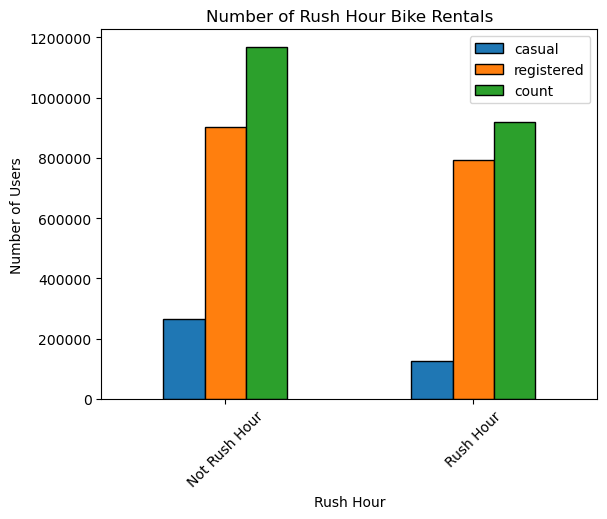

In [591]:
# bar chart for the number of rush hour bike rentals
ax = rentals_rush_hour.plot(kind="bar", edgecolor="black")
plt.title("Number of Rush Hour Bike Rentals")
plt.xlabel('Rush Hour')
plt.ylabel("Number of Users")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.show()


**Trends Over Time**

For the time based trend, we are looking at the temperatures as well as the "feel like" temperature across the months. From the graph, it is shown that the "feel like" temperature is always heigher than the actual temperature. Comparing that graph to the graph of the number of users per month, the temperatures and the users have a steady increase until the June and July months, and then they begin to lower. For the users, it basically levels out and then begins to drop after October, ie., colder weather.

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\1943312040.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_temperature = bikes.groupby("month")[["temp", "atemp"]].mean()


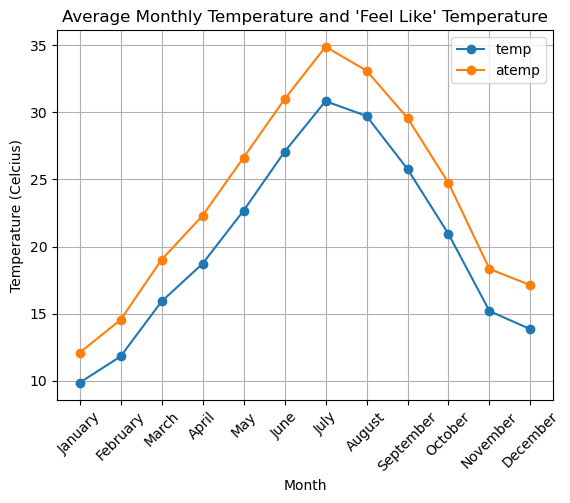

C:\Users\19143\AppData\Local\Temp\ipykernel_24320\1943312040.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_users = bikes.groupby("month")[["casual", "registered"]].sum()


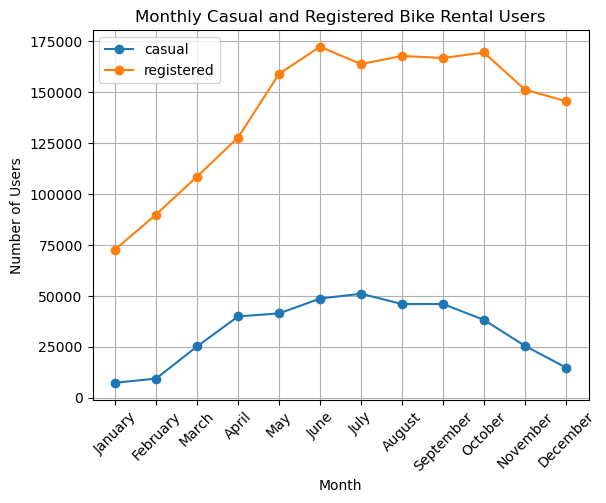

In [655]:
# variable for the temperatures across the months
monthly_temperature = bikes.groupby("month")[["temp", "atemp"]].mean()

# line graph of the temperatures across the months
monthly_temperature.plot(kind="line", marker="o")
plt.xticks(ticks=range(len(monthly_temperature.index)),labels=monthly_temperature.index, rotation=45)
plt.title("Average Monthly Temperature and 'Feel Like' Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (Celcius)")
plt.legend()
plt.grid()
plt.show()

# casual and registered users across the months
monthly_users = bikes.groupby("month")[["casual", "registered"]].sum()

# line graph of the rental users across the months
monthly_users.plot(kind="line", marker="o")
plt.xticks(ticks=range(len(monthly_users.index)),labels=monthly_users.index, rotation=45)
plt.title("Monthly Casual and Registered Bike Rental Users")
plt.xlabel("Month")
plt.ylabel("Number of Users")
plt.legend()
plt.grid()
plt.show()



**Variable Relationships**

This section is exploring the different numerical variable relationships through correlation. By comparing them, we can better understand the factors that connect to higher or lower bike rentals. First, we generate the correlation table created to see the strengths between the numerical columns. This shows how the variables move against or with one another.

In [607]:
# getting the correlation between the numerical values
corr_table = bikes[columns_numerical].corr()
corr_table

,temp,atemp,humidity,windspeed,casual,registered,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948
count,0.394454,0.389784,-0.317371,0.101369,0.690414,0.970948,1.000000


From the correlation table above, the highest correlations are:
1. temperature and "feel like" temperature with an extremely strong positive relationship 0.984948. The 'feel like' temperature does come from the actual temperature, so they move with one another, moving nearly identically.
2. humidity and casual with a negative relationship of -0.348187. This suggests that higher humidity makes outside uncomfortable, resulting in less casual bike rentals.
3. windspeed and humidity with a negative relationship of -0.318607. Higher windspeed can lower humidity, as provides a breeze and movement in the air.
4. casual and count with a decently strong relationship of 0.690414. As the casual bike rentals increase, the total amount of riders increases.
5. registered and count with a strong positive relationship of 0.970948. As the registered bike rentals increase, the total amount of riders increases.

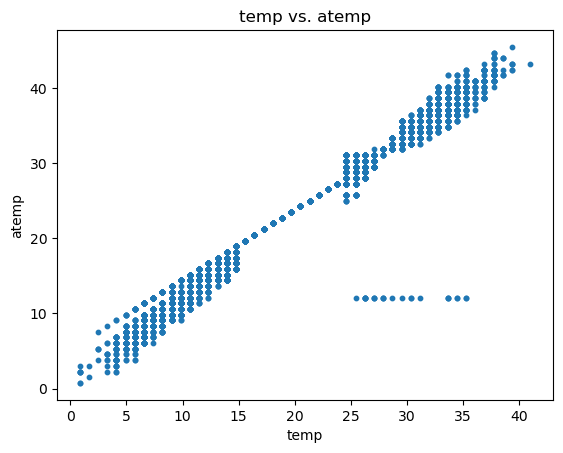

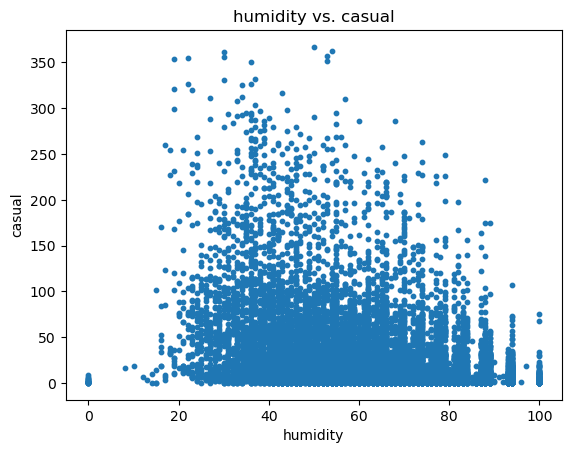

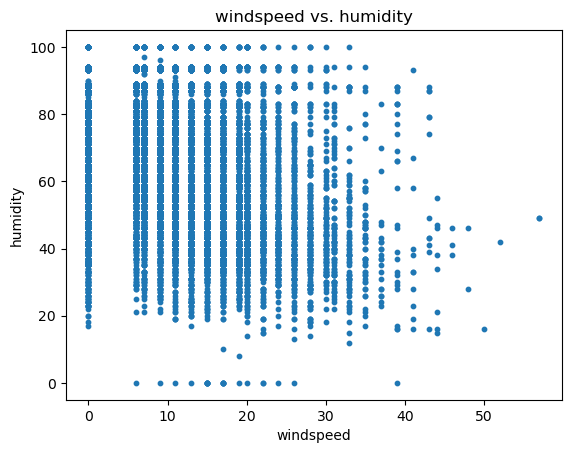

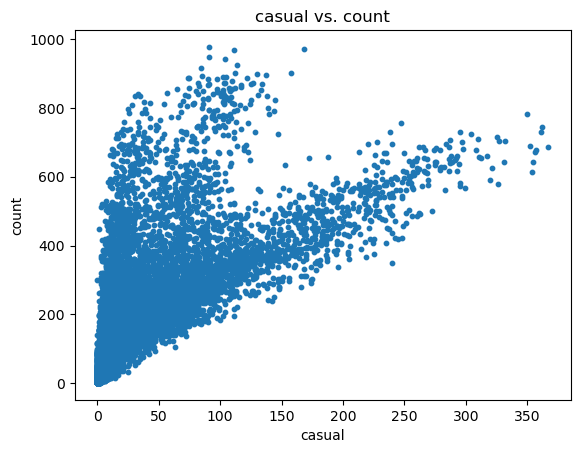

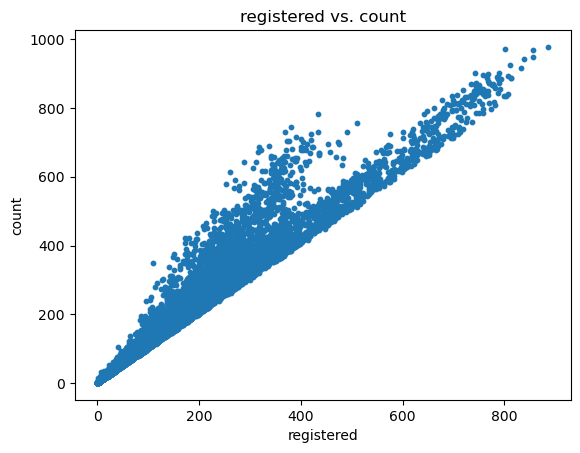

In [ ]:
# plotting multiple scatter plots to show correlation relationship
def bike_scatter(df, col1, col2, size=10):
  ''' 
  takes two columns in a dataframe and creates a scatter plot to show their relationship
  '''
  plt.scatter(df[col1], df[col2], s=size)
  plt.title(f"{col1} vs. {col2}")
  plt.xlabel(f"{col1}")
  plt.ylabel(f"{col2}")
  plt.show()

# plot temp against atemp
bike_scatter(bikes, "temp", "atemp")

# plot humidity and casual
bike_scatter(bikes, "humidity", "casual")

# plot windspeed and humidity
bike_scatter(bikes, "windspeed", "humidity")

# # plot casual and count
bike_scatter(bikes, "casual", "count")

# # plot registered and count
bike_scatter(bikes, "registered", "count")

A "something new" by building a correlation heatmap. The heatmap matches the above correlation table.

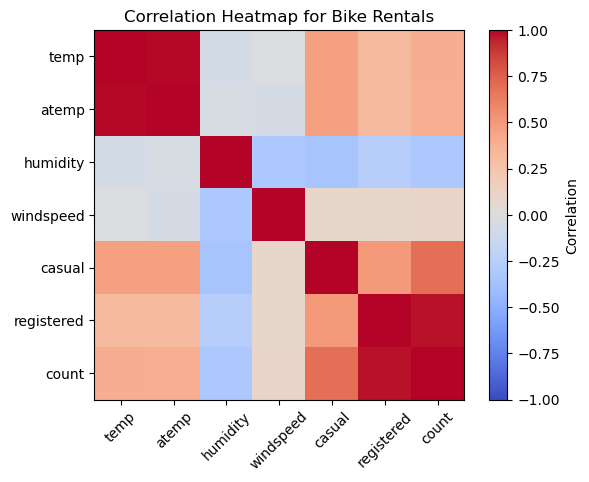

In [647]:
plt.imshow(corr_table, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Correlation Heatmap for Bike Rentals")
plt.xticks(range(len(corr_table)), corr_table.columns, rotation=45)
plt.yticks(range(len(corr_table)), corr_table.columns)
plt.show()

**Hypothesis**

As the 'feel like' temperature increases, the number of bike rentals also increases. Warmer weather tends to be more comfortable for outdoor activities. When the 'feel like' temperature feels decent, people are more likely to choose outdoor activities like biking.

**Linear Regression**

Linear Regression will be used here to see if 'feels like' temperature has a predicable relationship with the total amount of bike rentals. Regression modeling will help to show if the rentals will increase, decrease, or stay the same as the 'feels like' temperature changes. So, we will be using atemp as the predictor variable and count as the outcome variable. The model will be fit, predicted v actual values plotted, and a regression line plotted.

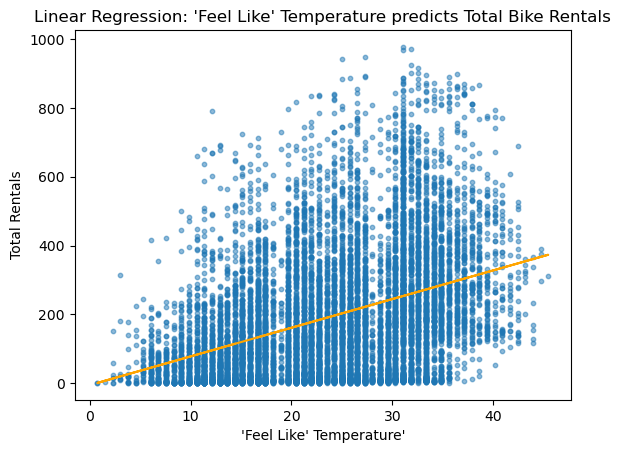

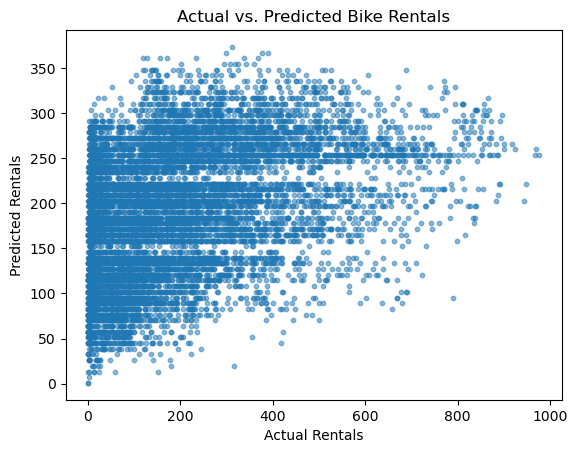

In [ ]:
# import Linear Regression
from sklearn.linear_model import LinearRegression

# linearRegression requires x to be 2 dimensional, so this needs to be reshaped.
x = bikes["atemp"].values.reshape(-1,1)
y = bikes["count"]

# fitting the model
bikes_model = LinearRegression()
bikes_model.fit(x, y)

# prediction variable
bike_predictions = bikes_model.predict(x)

# plotting scatterplot against the linear regression line
plt.scatter(bikes["atemp"], bikes["count"], alpha=0.5, s=10)
# regression line
plt.plot(bikes["atemp"], bike_predictions, color="orange")
plt.title("Linear Regression: 'Feel Like' Temperature predicts Total Bike Rentals")
plt.xlabel("'Feel Like' Temperature'")
plt.ylabel("Total Rentals")
plt.show()


# plotting actual vs. predicted
plt.scatter(y, bike_predictions, alpha=0.5, s=10)
plt.title("Actual vs. Predicted Bike Rentals")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")
plt.show()


**Regression Discussion**


From the regression line in the first graph above, there is a positive relationship between the 'feel like' temperature and the total number of bike rentals. When the 'feel like' temperature is warmer, users are more likely to do outdoor activities, like rent a bike. The overall slope is positive.

The model is not perfect, but it does roughly predict within the same range for the number of rentals. It isn't quite able to match the higher or lower rental counts. It's good at shows the direction of our hypothesis, the higher the temperature, the increase in bike rentals. But, it isn't great at predicting the exact count.

A limitation is not incorporating any other factors in the dataset, such as the weather, season, holiday, time of year, etc. Also temperatures can reach a point that it's too hot to do any outdoor activities.



**Reflection / Conclusion**

This data set explored how weather, time, season, and user type relates to the number of bike rentals.<br>

Overall, the bike rental numbers were shaped by multiple factors. The one I chose to dig the most into how the rental numbers differed by temperature, 'feel like' temperature, time of day, and the months of the year. Being able to change columns from numerical to categorical and add additional columns helped in showing the clear differences and similarities.<br>

With temperature, for both actual and 'feel like', there was a general strong relationship between them and rentals. When the temperature increased, so did the number of total bike rentals. This moves alongside with the months. As the year goes on, month by month the number of rentals increases. This is only the case until Fall, when the rental numbers drop later in the year.

Registered bike renters made up most of the data. Casual bike renters were slower to increase their rentals through the year and the temperature, but they did still increase and decrease along with the registered bike renters. There wasn't a change in relationship compared to the registered bike renters.

The correlation between some of the columns showed there was more of a relationship numerically, which is something that should be investigated alongside temperature and rental numbers.

From this final project, I have a deeper understanding of exploratory data analysis. There were so many directions to go down, it was difficult to pick to one avenue and expand beyond the project. I could easily see multple additional hours going into this data from different angles, especially when going into the weather, humidity, and hours of the day.

In the future, multivariable models and adding location data. Based on the location of this data, that can help to decipher why the Spring bike rentals were lower than the Winter bike rentals. Also, deeper comparisions into workday versus a holiday and a weekend versus a weekday.

In conclusion, there are a variety of factors that influence the number of bike rentals across casual and registered bike riders. With my analysis, temperature had a positive relationship with the bike rentals. When the temperature and 'feel like' temperature increased, the number of bike rentals tended to move within the same range.

